In [ ]:
#Carregar BD
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#Informações do BD

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


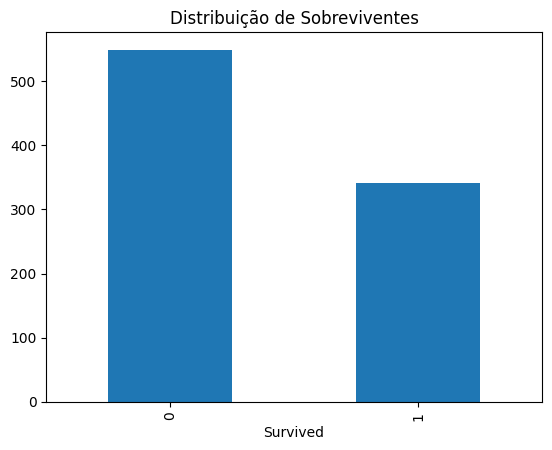

In [ ]:
#Distribução de sobreviventes

import matplotlib.pyplot as plt

df["Survived"].value_counts().plot(kind="bar")

plt.title("Distribuição de Sobreviventes")
plt.show()

<Axes: xlabel='Pclass', ylabel='count'>

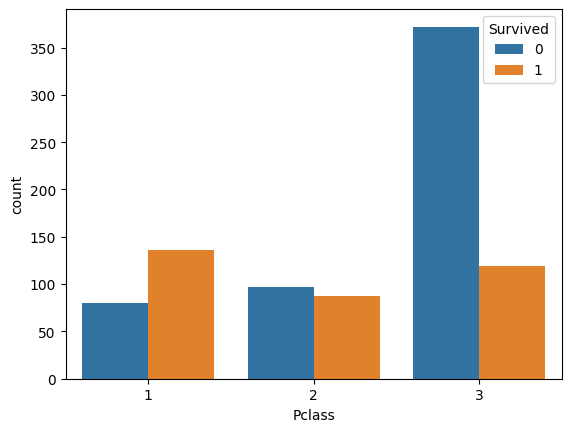

In [ ]:
#Sobreviventes por Classe

import seaborn as sns

sns.countplot(data=df,
              x="Pclass",
              hue="Survived")

In [ ]:
#Removendo colunas desnecessarias para analise (limpeza)

df = df.drop(
    columns=[
        "PassengerId",
        "Name",
        "Ticket",
        "Cabin"
    ]
)

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median()) #Substitui idaddes faltantes pela mediana

df["Embarked"] = df["Embarked"].fillna(          #Substitui portos de embarque faltantes pelo valor mais frequente
    df["Embarked"].mode()[0]
)

df["Sex"] = df["Sex"].map({                      #Substitui por numeros o sexo
    "male":0,
    "female":1
})

df = pd.get_dummies(
    df,
    columns=["Embarked"],
    drop_first=True
)

X = df.drop("Survived", axis=1)                  #Sobreviveu ou não

y = df["Survived"]

In [ ]:
from sklearn.model_selection import train_test_split #Divide o codigo em treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler #normalização de valores

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier #Cria o KNN, compara com os 5 vizinhos mais proximos

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn = knn.predict(X_test) #Avaliar desempenho do KNN

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

#Calcular acuracia
print(
    accuracy_score(
        y_test,
        y_pred_knn
    )
)
#apresentar métricas
print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

0.8044692737430168
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



<Axes: >

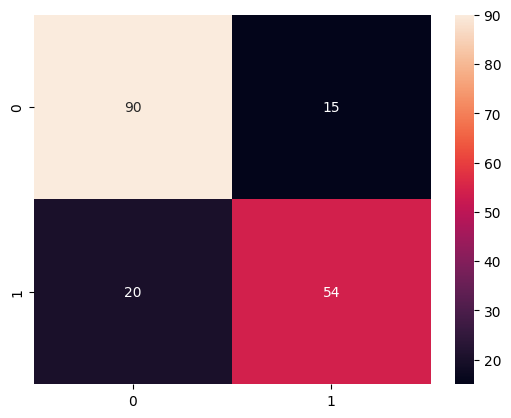

In [ ]:
#Esse gráfico é uma matriz de confusão (confusion matrix). Ele mostra onde o modelo acertou e onde errou.
sns.heatmap(
    confusion_matrix(y_test, y_pred_knn),
    annot=True,
    fmt="d"
)

In [ ]:
#importa do modelo de rede neural

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [ ]:
y_pred_mlp = mlp.predict(X_test) #Rede recebe passageiro que nunca viu para teste

In [ ]:
#Calcula acuracia

print(
    accuracy_score(
        y_test,
        y_pred_mlp
    )
)

print(
    classification_report(
        y_test,
        y_pred_mlp
    )
)

0.8100558659217877
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       105
           1       0.81      0.70      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



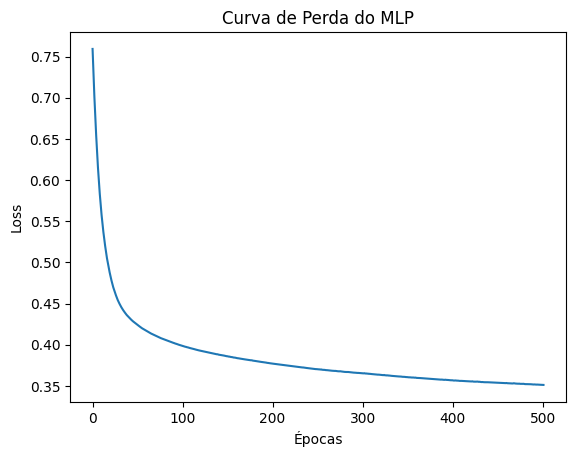

In [ ]:
plt.plot(mlp.loss_curve_) #Mostra a diminuição dos erros do modelos

plt.title("Curva de Perda do MLP")
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.show()

In [ ]:
#Comparar os dois modelos acuracia
resultado = pd.DataFrame({
    "Modelo":["kNN","MLP"],
    "Acurácia":[
        accuracy_score(y_test,y_pred_knn),
        accuracy_score(y_test,y_pred_mlp)
    ]
})

resultado

,Modelo,Acurácia
0,kNN,0.804469
1,MLP,0.810056


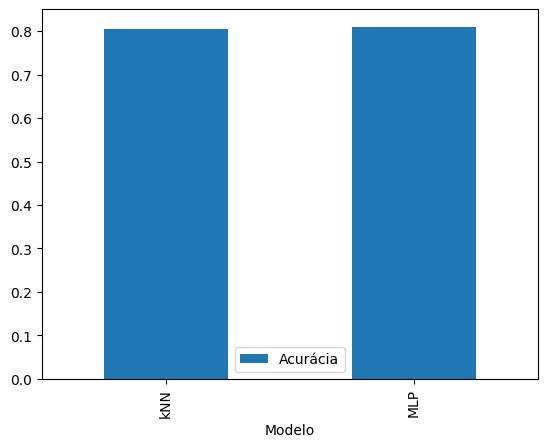

In [ ]:
#COmpara a acuracia dos dois modelos
resultado.plot(
    x="Modelo",
    y="Acurácia",
    kind="bar"
)

plt.show()

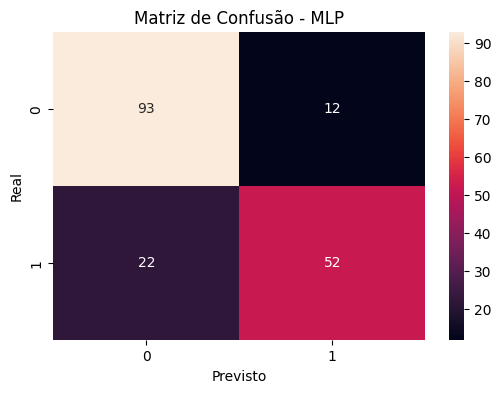

In [ ]:
#Matriz de confusão do MLP, mostra onde o modelo acertou e errou

plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_mlp),
    annot=True,
    fmt="d"
)

plt.title("Matriz de Confusão - MLP")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

In [ ]:
#Métricas completas do MLP e KNN

from sklearn.metrics import precision_score, recall_score, f1_score

comparacao = pd.DataFrame({
    "Modelo": ["kNN", "MLP"],
    "Acurácia": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_mlp)
    ],
    "Precisão": [
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_mlp)
    ],
    "Recall": [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_mlp)
    ],
    "F1": [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_mlp)
    ]
})

comparacao

,Modelo,Acurácia,Precisão,Recall,F1
0,kNN,0.804469,0.782609,0.729730,0.755245
1,MLP,0.810056,0.812500,0.702703,0.753623
